# Chapter 1 - Introducing Token Factory (and Nemotron)

**AI Agent Course** · Nebius Token Factory × NVIDIA

**Goal:** by the end of this chapter you will have a Token Factory account, understand what a model card tells you, have made your first chat completion call in the UI and in Python, made a first (manual) tool call, and know where to look for usage and cost data.

**Prerequisites:** Python 3.10+, basic familiarity with REST APIs. No GPU, no prior LLM experience assumed.

**Deliverable:** a small Python script that calls Nemotron 3 Ultra, asks it to emit a structured JSON tool call, executes the tool locally, and returns the result to the model — this is the basis of the agent we scale in the next chapters.

## 1. What is Token Factory?

Token Factory is **managed inference for open-source models**. You don't manage GPUs or serving stacks - Token Factory handles inference for you.

Two ways to consume it:

| | Serverless | Dedicated endpoints |
|---|---|---|
| Billing | Pay per token | Pay per GPU-hour |
| Best for | Getting started, spiky traffic | High, steady throughput; custom configs |

**We only use serverless in this course.**

### The model catalog

The catalog hosts frontier open models: **GLM 5.2**, **Kimi**, **Qwen**, and the **NVIDIA Nemotron family**, among others. Our flagship for this course is **Nemotron 3 Ultra** — and Nemotron models will return in the fine-tuning chapter (teacher/student).

### Why "OpenAI-compatible API" matters

Token Factory exposes an OpenAI-compatible API. That means:

- The entire ecosystem of SDKs and tools works out of the box
- Drop-in migration from other providers
- Every tutorial on the internet works with a **one-line `base_url` change**

## 2. Creating an account and getting a key

1. Sign up / log in to the **Nebius console**
2. Navigate to **Token Factory**
3. Create an **API key**

### Key hygiene (do this from day one)

This is the first appearance of the course's recurring **security** thread:

- Store keys in **environment variables**, never in code
- **Never commit keys** — use a `.env` file and add it to `.gitignore`

Set the key in your shell:

In [ ]:
# Run this in your terminal (not in the notebook):
#   export NEBIUS_API_KEY="..."
#
# Or, for this notebook session only, uncomment and set it here —
# just never commit a notebook with a real key in it:
# import os
# os.environ["NEBIUS_API_KEY"] = "..."

import os
assert os.environ.get("NEBIUS_API_KEY"), "NEBIUS_API_KEY is not set!"
print("API key found ✔")

## 3. Reading a model card

We'll use **Nemotron 3 Ultra** as the running example. Here's what to look for on a model card, and why each field matters to an engineer:

| Field | Why you care |
|---|---|
| **Context length** | What fits in 128k/200k tokens in practice — a book? a codebase? (Foreshadows the memory/context chapter.) |
| **Modality** | Text vs. multimodal. |
| **Pricing** | Input vs. output token price; why output tokens cost more; cached-input pricing if shown. |
| **Benchmarks** | How to read them *skeptically* — eyeball testing beats leaderboard worship (Module 1.2). |

### ✏️ Exercise

Compare the **GLM 5.2** card against a **small Nemotron** card. Which would you pick for:

- (a) a chat summarizer?
- (b) a high-volume classification workload?

Note the **~10–50× price gap** — "the biggest model" is rarely the answer.

## 4. One minute on how inference actually works

Let's dispel the magic:

- Models read and write **tokens**, not words. Tokens are the billing and performance metric.
- Key performance metrics you'll meet again in the observability section:
  - **TTFT** — Time To First Token
  - **TPOT** — Time Per Output Token
  - **E2EL** — End-to-End Latency

## 5. First calls in the UI (Playground)

Before any code, use the **Token Factory playground**:

1. Pick **Nemotron 3 Ultra**, write a system prompt, chat.
2. Change **temperature** and **max tokens**; observe how the output changes.
3. Look at the **token counter** and connect it to pricing — "this conversation cost \$0.0004".
4. **Eyeball-test** the same prompt on a small Nemotron model side by side.

That last step is your first informal model comparison — the rigorous version arrives in Module 1.2.

## 6. The Chat Completions request

### 6.1 Anatomy of the request

Before the code, the pieces:

- **`model`** — the catalog ID.
- **`messages`** — the conversation as a list of roles (`system`, `user`, `assistant`, and later `tool`). **Key mental model: the API is stateless — you send the whole history every time.**
- **Sampling params** — `temperature`, `top_p`, `max_tokens`.
- **The response object** — `choices[0].message.content`, `finish_reason`, and crucially for this course, **`usage`** (prompt/completion tokens), which is our cost signal.

### 6.2 Minimal call

The model card provides a ready-made snippet (the one below is adapted from it) — that's where you grab it:

In [ ]:
import os
from openai import OpenAI

client = OpenAI(
    base_url="https://api.tokenfactory.us-central1.nebius.com/v1/",
    api_key=os.environ.get("NEBIUS_API_KEY"),
)

SYSTEM_PROMPT = "You are a concise assistant for a market-research team."
USER_MESSAGE = "In two sentences, what does NVIDIA's Nemotron model family target?"

response = client.chat.completions.create(
    model="nvidia/Nemotron-3-Ultra-550b-a55b",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": """Hello, how is your day going?"""
                }
            ]
        }
    ]
)

print(response.choices[0].message.content)
print("---")
print("finish_reason:", response.choices[0].finish_reason)
print("usage:", response.usage)

Expected output looks like:

```
NVIDIA's Nemotron model family targets enterprise applications by providing customizable AI models optimized for business-specific workflows and industry use cases. These models are designed to integrate seamlessly with NVIDIA's hardware and software ecosystem, enabling efficient deployment for tasks like customer service, content generation, and data analysis.
---
finish_reason: stop
usage: CompletionUsage(completion_tokens=57, prompt_tokens=34, total_tokens=91, ...)
```

**Try it yourself:**
- Run `response.to_json()` once to see the **full** response object — then get in the habit of reaching straight for `choices[0].message.content` and `usage`.
- Set `max_tokens` to something tiny (e.g. `5`) and re-run. You'll see `finish_reason == "length"` — your first taste of **LLM failure modes**.

In [ ]:
# See the full response object once, then never print it all again :)
print(response.to_json())

In [ ]:
# What happens when max_tokens is too small?
truncated = client.chat.completions.create(
    model="nvidia/Nemotron-3-Ultra-550b-a55b",
    messages=[{"role": "user", "content": "Explain what a token is."}],
    max_tokens=5,
)
print("content:", truncated.choices[0].message.content)
print("finish_reason:", truncated.choices[0].finish_reason)  # -> "length" 

### 6.3 Streaming

Tokens arrive one by one because generation is sequential (remember prefill vs. decode from Section 4). Streaming lets you show them as they're produced — this is where **TTFT** vs. **tokens-per-second** becomes visible; both return in the observability section.

In [ ]:
stream = client.chat.completions.create(
    model="nvidia/Nemotron-3-Ultra-550b-a55b",
    messages=[{"role": "user", "content": "Explain prefill vs decode in 3 sentences."}],
    stream=True,
)
for chunk in stream:
    delta = chunk.choices[0].delta.content
    if delta:
        print(delta, end="", flush=True)
print()

Expected output (yours will vary):

```
Prefill is the initial forward pass where the model processes the entire input prompt in parallel, computing hidden states for every token at once. Decode then runs autoregressively, generating one new token at a time while reusing the cached key/value states from the prefill step. This split lets the model handle large prompts efficiently during prefill and keep latency low during incremental token generation.
```

### 6.4 Multi-turn = resending history

The API is stateless. "Memory" is just you resending the conversation:

In [ ]:
history = [{"role": "system", "content": SYSTEM_PROMPT}]

def ask(user_text: str) -> str:
    history.append({"role": "user", "content": user_text})
    resp = client.chat.completions.create(
        model="nvidia/Nemotron-3-Ultra-550b-a55b",
        messages=history,
    )
    answer = resp.choices[0].message.content
    history.append({"role": "assistant", "content": answer})
    return answer

print(ask("Name three open-weight LLM families."))
print(ask("Which of those did NVIDIA make?"))  # works only because we resent history

**Point to notice:** cost grows with history length — every turn re-pays for the *whole* prompt. This motivates prompt caching, and much later, memory design in Mini-course 3.

## 7. A very simple tool call

**Framing:** a *tool* is just a function; a *tool call* is just the model asking us to run it.

We meet tool calling in three passes:

1. **Visually**, in the model card UI
2. A **bare-bones manual version** in Python (model emits JSON, we parse and execute)
3. A **preview of the native tools API**

This dispels the magic before frameworks hide it.

### 7.0 First contact: tool calling in the model card UI

Before writing any code:

1. Open the **Nemotron 3 Ultra** model card and find the **tools panel**.
2. Insert a function definition as JSON via the UI (use the `get_weather` schema below — the same one we'll use in code).
3. Ask **"What's the weather in Amsterdam?"** and watch the model respond with a *tool call* instead of an answer.

Notice what the UI shows: the function name, the parsed arguments, and the fact that **nothing was executed** — the model only produced a *request*. Someone (soon: our Python code) has to run the function and hand the result back.

The function JSON to paste into the UI:

```json
{
  "name": "get_weather",
  "description": "Get current weather for a city",
  "parameters": {
    "type": "object",
    "properties": {
      "city": {"type": "string"}
    },
    "required": ["city"]
  }
}
```

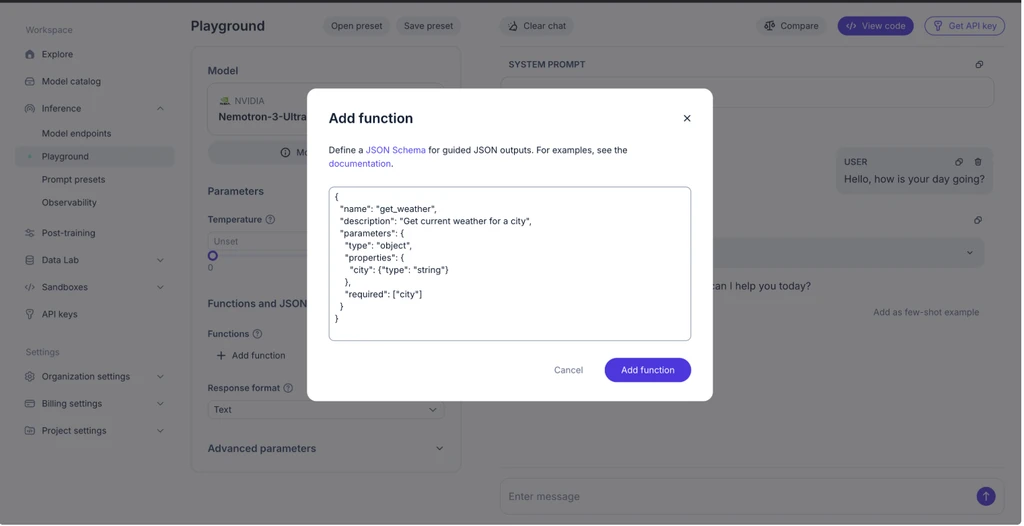

Now that you've seen it, let's rebuild it from scratch.

### 7.1 Manual JSON "tool call" (no API features at all)

When you ask an LLM to calculate a math equation, does it actually do computation? At the basic level — not really. It is familiar with mathematical concepts and expressions from its training, so it outputs information it *knows* rather than what it verifies by crunching numbers.

Let's create a **calculator tool** in Python that our LLM can actually use, so its answers are grounded in computation.

In [ ]:
import json
import sympy

TOOL_SYSTEM_PROMPT = """You can use one tool:
calculate(expression: str) -> the exact result of an arithmetic expression
If the user's request needs the tool, respond with ONLY this JSON, no other text:
{"tool": "calculate", "arguments": {"expression": "<expression>"}}
Otherwise, answer normally."""

def calculate(expression: str) -> str:
    # SymPy parses and evaluates exactly: big ints, fractions, roots, constants.
    return str(sympy.sympify(expression))

messages = [
    {"role": "system", "content": TOOL_SYSTEM_PROMPT},
    {"role": "user", "content": "What's 4823 * 3917?"},
]

resp = client.chat.completions.create(
    model="nvidia/Nemotron-3-Ultra-550b-a55b",
    messages=messages,
    temperature=0,
)
raw = resp.choices[0].message.content
print("Model said:", raw)

call = json.loads(raw)
result = calculate(**call["arguments"])

# Feed the result back for a final answer
messages.append({"role": "assistant", "content": raw})
messages.append({"role": "user", "content": f"Tool result: {result}. Answer the user."})

final = client.chat.completions.create(
    model="nvidia/Nemotron-3-Ultra-550b-a55b",
    messages=messages,
)
print(final.choices[0].message.content)

**Discussion points:**

- **What breaks?** The model may wrap JSON in prose or code fences, hallucinate arguments, or call a tool that doesn't exist. → This motivates **structured outputs** (Module 1.2) and **native tool calling**.
- **The model never executes anything. Your code does.** This is the safety foundation for Module 2.1.

### 7.2 The same thing with the native tools API (preview)

In [ ]:
tools = [{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get current weather for a city",
        "parameters": {
            "type": "object",
            "properties": {"city": {"type": "string"}},
            "required": ["city"],
        },
    },
}]

resp = client.chat.completions.create(
    model="zai-org/GLM-5.2",
    messages=[{"role": "user", "content": "Weather in Amsterdam?"}],
    tools=tools,
)
tc = resp.choices[0].message.tool_calls[0]
print(tc.function.name, tc.function.arguments)  # get_weather {"city": "Amsterdam"}

Same idea — but the JSON contract is **enforced by the API** and the model was fine-tuned for it. The full loop (executing, `role: "tool"` messages, multiple rounds) is the opening of Module 2.1, and the first real tool we plug in will be **Tavily** (next chapter).

## 8. Observability and cost management

**Theme statement for the whole course:** if you can't see what your LLM calls cost and how they behave, you don't have something production-grade. Costs can blow up fast!

Here we cover the built-in layer; the DIY layer (Prometheus/Grafana, MLflow) comes in Modules 1.3–1.4.

### Console usage dashboard

The Token Factory console shows **tokens and spend per model, per key, over time**. Take a minute to walk through it now.

### Per-request usage: log it yourself from day one

Minimal pattern:

In [ ]:
import time, logging

logging.basicConfig(level=logging.INFO, format="%(message)s")

PRICE_IN, PRICE_OUT = 1.00, 3.00  # $/1M tokens for Nemotron 3 Ultra

def tracked_completion(**kwargs):
    t0 = time.perf_counter()
    resp = client.chat.completions.create(**kwargs)
    latency = time.perf_counter() - t0
    u = resp.usage
    cost = (u.prompt_tokens * PRICE_IN + u.completion_tokens * PRICE_OUT) / 1e6
    logging.info(
        f"model={kwargs['model']} in={u.prompt_tokens} out={u.completion_tokens} "
        f"latency={latency:.2f}s cost=${cost:.6f}"
    )
    return resp

# Try it:
_ = tracked_completion(
    model="nvidia/Nemotron-3-Ultra-550b-a55b",
    messages=[{"role": "user", "content": "Say hi in five words."}],
)

### Latency

- **Time-to-first-token** vs. **total time** are different numbers with different levers.
- **Output length is the main lever** on total latency.
- A cheaper, smaller model is often also the *faster* model.

### Cost levers (a recurring checklist for the whole course)

1. **Smaller model where quality allows** — remember the bigger vs. smaller Nemotron comparison from earlier.
2. **Shorter prompts and outputs** — `max_tokens`, concise system prompts.
3. **Prompt/prefix caching** — repeated system prompts can be much cheaper; details later.
4. **Batch/off-peak processing** for non-interactive workloads.

### Rate limits and quotas

- Know what a **429** looks like.
- Exponential backoff in three lines.
- **Set spend limits per key** so a runaway agent can't burn the budget — this becomes very real once agents run loops in Mini-course 2.

In [ ]:
# Exponential backoff in three lines (plus scaffolding)
import time
from openai import RateLimitError

def with_backoff(fn, retries=5):
    for attempt in range(retries):
        try:
            return fn()
        except RateLimitError:  # HTTP 429
            wait = 2 ** attempt
            print(f"429 received — backing off {wait}s")
            time.sleep(wait)
    raise RuntimeError("Still rate-limited after retries")

## 9. Exercises

**1. Model card scavenger hunt.** For Nemotron 3 Ultra and one other model, fill in the table: context length, input/output price, license, one benchmark number. Then compute the cost of one **50k-in / 1k-out** request on each.

**2. Eyeball eval.** Run the same 5 prompts (provided) on both models in the playground; rank the outputs; write two sentences on where the small model was *good enough*.

**3. Tracked client.** Extend `tracked_completion` to accumulate a session total and **refuse to run past a \$0.05 budget**.

**4. Tool call hardening (stretch).** Make the manual JSON tool call survive the model wrapping JSON in ``` fences, and reject unknown tool names.

In [ ]:
# Exercise 1 — Model card scavenger hunt
# Fill in the values from the model cards:

cards = {
    "nvidia/Nemotron-3-Ultra-550b-a55b": {
        "context_length": None,   # tokens
        "price_in": None,         # $/1M input tokens
        "price_out": None,        # $/1M output tokens
        "license": None,
        "benchmark": None,        # e.g. ("MMLU", 0.0)
    },
    "your/second-model-here": {
        "context_length": None,
        "price_in": None,
        "price_out": None,
        "license": None,
        "benchmark": None,
    },
}

def request_cost(card, tokens_in=50_000, tokens_out=1_000):
    return (tokens_in * card["price_in"] + tokens_out * card["price_out"]) / 1e6

# for name, card in cards.items():
#     print(name, f"${request_cost(card):.4f}")

In [ ]:
# Exercise 3 — Budgeted tracked client (starter)

class BudgetedClient:
    def __init__(self, budget_usd=0.05):
        self.budget = budget_usd
        self.spent = 0.0

    def completion(self, **kwargs):
        if self.spent >= self.budget:
            raise RuntimeError(f"Budget of ${self.budget:.2f} exhausted (spent ${self.spent:.4f})")
        resp = client.chat.completions.create(**kwargs)
        u = resp.usage
        self.spent += (u.prompt_tokens * PRICE_IN + u.completion_tokens * PRICE_OUT) / 1e6
        return resp

# TODO: try it, then break it — what happens on the request that *crosses* the budget?

In [ ]:
# Exercise 4 (stretch) — Tool call hardening (starter)

KNOWN_TOOLS = {"calculate": calculate}

def parse_tool_call(raw: str) -> dict:
    """Return the parsed tool call, surviving ```-fenced JSON.
    Raise ValueError for unknown tool names or malformed JSON."""
    # TODO:
    # 1. Strip markdown code fences (```json ... ```) if present
    # 2. json.loads the remainder
    # 3. Check call["tool"] is in KNOWN_TOOLS
    raise NotImplementedError

## 10. Handoff to the next chapter

We now know how to **call a model** and how to make it **request an action as JSON**. But our weather tool was fake, and our calculator only does math.

The obvious first *real* tool is **web search** — enter **Tavily**, and with it, the first genuine Pythonic agentic loop.